In [1]:
from medmnist import ChestMNIST
from torchvision.transforms import v2
import torch

tf = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32,scale=True)
])

train_data = ChestMNIST(split='train',transform=tf,download=True,root="./data")
val_data = ChestMNIST(split='val',transform=tf,download=True,root="./data")
test_data = ChestMNIST(split='test',transform=tf,download=True,root="./data")

In [2]:
train_data.info

{'python_class': 'ChestMNIST',
 'description': 'The ChestMNIST is based on the NIH-ChestXray14 dataset, a dataset comprising 112,120 frontal-view X-Ray images of 30,805 unique patients with the text-mined 14 disease labels, which could be formulized as a multi-label binary-class classification task. We use the official data split, and resize the source images of 1×1024×1024 into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/chestmnist.npz?download=1',
 'MD5': '02c8a6516a18b556561a56cbdd36c4a8',
 'url_64': 'https://zenodo.org/records/10519652/files/chestmnist_64.npz?download=1',
 'MD5_64': '9de6cd0b934ebb5b7426cfba5efbae16',
 'url_128': 'https://zenodo.org/records/10519652/files/chestmnist_128.npz?download=1',
 'MD5_128': 'db107e5590b27930b62dbaf558aebee3',
 'url_224': 'https://zenodo.org/records/10519652/files/chestmnist_224.npz?download=1',
 'MD5_224': '45bd33e6f06c3e8cdb481c74a89152aa',
 'task': 'multi-label, binary-class',
 'label': {'0': 'atelectasis',
  '1': 'cardi

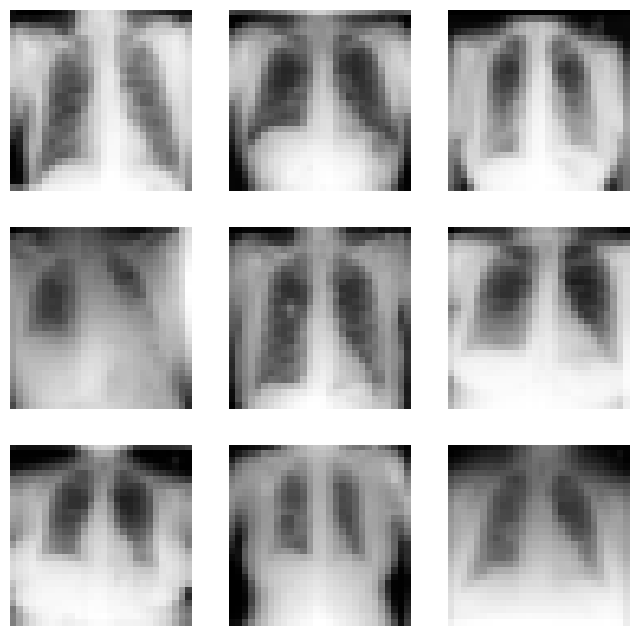

torch.Size([1, 28, 28])

In [3]:
import matplotlib.pyplot as plt
import torch

labels_map = {
    0: 'atelectasis',
    1: 'cardiomegaly',
    2: 'effusion',
    3: 'infiltration',
    4: 'mass',
    5: 'nodule',
    6: 'pneumonia',
    7: 'pneumothorax',
    8: 'consolidation',
    9: 'edema',
    10: 'emphysema',
    11: 'fibrosis',
    12: 'pleural',
    13: 'hernia',
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.axis("off")
    plt.imshow(img.permute(1,2,0), cmap="gray")
plt.show()

train_data[0][0].size()

In [4]:
from torch.utils.data import DataLoader

train_dl = DataLoader(train_data,batch_size=1024,shuffle=True)
val_dl = DataLoader(val_data,batch_size=1024,shuffle=True)
test_dl = DataLoader(test_data,batch_size=1024,shuffle=True)

In [5]:
from model import ResNet18
from train_settings import Train_Settings

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

classes = len(train_data.info["label"])
channels = train_data.info["n_channels"]

model = ResNet18(channels,classes).to(device)

#config = Train_Settings(model=model,learning_rate=0.1,decay_rate=0.0)

# model is not used for training just parameters
loss = torch.nn.BCEWithLogitsLoss()
learning_rate = 1e-5
optimiser = torch.optim.Adam(params=model.parameters(),lr=learning_rate)

config = (loss,device,optimiser),(loss,device)

In [6]:
logs = [[[],[]],[[],[]]]

In [7]:
print(model)

ResNet18(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layers64): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): Bat

In [8]:
from functions import train_val_loop
train_val_loop(model,config,(train_dl,val_dl),100,logs)

Epoch : 1
loss: 0.689776  [ 1024/78468]
loss: 0.524224  [26624/78468]
loss: 0.395509  [52224/78468]
loss: 0.318155  [77824/78468]
Train Error: 
 Accuracy: 83.4%, Avg loss: 0.469949 

Test Error: 
 Accuracy: 94.7%, Avg loss: 0.319713 

Epoch : 2
loss: 0.315805  [ 1024/78468]
loss: 0.277444  [26624/78468]
loss: 0.254683  [52224/78468]
loss: 0.244990  [77824/78468]
Train Error: 
 Accuracy: 94.8%, Avg loss: 0.270218 

Test Error: 
 Accuracy: 94.9%, Avg loss: 0.241147 

Epoch : 3
loss: 0.237077  [ 1024/78468]
loss: 0.230660  [26624/78468]
loss: 0.227243  [52224/78468]
loss: 0.219522  [77824/78468]
Train Error: 
 Accuracy: 94.9%, Avg loss: 0.226796 

Test Error: 
 Accuracy: 94.9%, Avg loss: 0.214723 

Epoch : 4
loss: 0.218456  [ 1024/78468]
loss: 0.208725  [26624/78468]
loss: 0.203619  [52224/78468]
loss: 0.202743  [77824/78468]
Train Error: 
 Accuracy: 94.9%, Avg loss: 0.207613 

Test Error: 
 Accuracy: 94.9%, Avg loss: 0.200657 

Epoch : 5
loss: 0.197879  [ 1024/78468]
loss: 0.196522  [266

[[[0.4699490194196825,
   0.2702184807170521,
   0.22679643681297054,
   0.20761304532552693,
   0.19617630231690097,
   0.18861353494130173,
   0.1832235020089459,
   0.1792184222828258,
   0.17609782187969653,
   0.17347973004564063,
   0.1711080532956433,
   0.1689201852717957,
   0.16681625471486675,
   0.1647130912774569,
   0.16251676190983166,
   0.1602799476354153,
   0.1580777448880208,
   0.1554147324391774,
   0.15287147404311538,
   0.1504136174917221,
   0.1473350983548474,
   0.14475040544163098,
   0.14171089696419703,
   0.13886298103766007,
   0.13571562782510535,
   0.13275262752136627,
   0.1300941402842472,
   0.12652202289212833,
   0.12366159821485544,
   0.12067133739784167,
   0.11743116640038305,
   0.11455774820083148,
   0.11160832972495587,
   0.10850624836884536,
   0.10545834753807488,
   0.10247561509733076,
   0.09955006828168769,
   0.09711688911760008,
   0.0945933081886985,
   0.09148841225481652,
   0.08881458417548761,
   0.08653526966060911,
   0.0

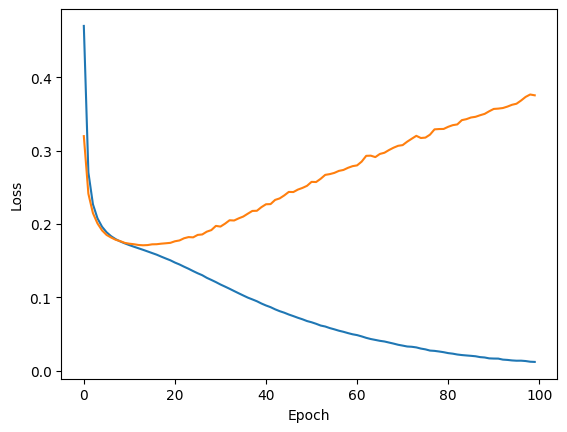

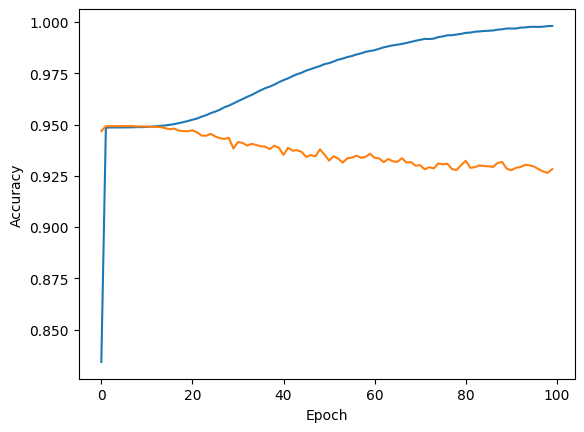

In [9]:
import matplotlib.pyplot as plt

plt.plot(logs[0][0])
plt.plot(logs[1][0])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.plot(logs[0][1])
plt.plot(logs[1][1])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

best accuracy + loss at : epoch 10

In [10]:
torch.save(model.state_dict(),"centralised_model.pth")

In [16]:
import json

d = json.dumps(logs)
f = open("centralised.json","w")

f.write(d)
f.close()